# Neural Network or Deep Learning

![Neural Network](ann.png)

from https://www.geeksforgeeks.org/artificial-intelligence/artificial-neural-networks-and-its-applications/


## Tensorflow Playground for Neural Network
https://playground.tensorflow.org/


## Types of Neural Networks

#### Feedforward Neural Network (FNN) or Artificial Neural Network (ANN)

- Simplest ANN type with unidirectional data flow
- No loops or feedback; data moves from input to output through hidden layers
- Used for basic classification and regression tasks

#### Convolutional Neural Network (CNN)

- Designed for grid-structured data like images
- Uses convolutional layers with filters to extract features (edges, textures)
- Effective for image and speech recognition
- Example: https://www.tensorflow.org/tensorboard/image_summaries

#### Recurrent Neural Network (RNN)

- Handles sequential data (time-series, text)
- Contains feedback loops providing network memory
- Ideal for speech recognition, language modeling, and forecasting

#### Long Short-Term Memory (LSTM)

- Advanced type of RNN designed to handle long-term dependencies
- Uses memory cells and gating mechanisms to retain or forget information
- Overcomes vanishing gradient problem in standard RNNs
- Excellent for sequence prediction, machine translation, and time-series analysis
- Gated Recurrent Unit (GRU): Simplified version of LSTM with fewer parameters

#### Transformer 

- https://www.kaggle.com/discussions/general/493003
- Modern architecture based on self-attention mechanisms
- Processes entire sequences simultaneously rather than sequentially
- Eliminates the need for recurrence, enabling parallel processing
- Foundation for large language models (GPT, BERT) and excels at NLP tasks
- Also applicable to computer vision and multimodal applications

### Key Optimization Algorithms

- Gradient Descent: Basic algorithm that updates weights using loss function gradients
- SGD (Stochastic Gradient Descent): Updates weights using single samples; faster but noisier, making it suitable for large datasets where computational efficiency is crucial.
- RMSprop: Adjusts learning rate based on recent gradients
- Adam: Efficient variant with adaptive learning rates for deep learning

### Main Challenges

- Data Dependency: Requires large amounts of high-quality data
- Computational Power: Demands significant resources and expensive hardware (GPU: graphics processing unit vs CPU: central processing unit)
- Overfitting: Risk of memorizing training data rather than generalizing
- Interpretability: "Black box" nature makes decision-making unclear

### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (12, 8)

import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install scikeras

In [3]:
# Sklearn_learn
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
    r2_score,
    mean_squared_error
)


# Tensorflow by Google
import tensorflow as tf
import tensorflow as keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier, KerasRegressor   


# Pytorch by Meta (Facebook AI)
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F


In [4]:
# Generate dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=18,
    n_redundant=2,
    n_classes=2,
    random_state=123
)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Building the ANN

Initializing the ANN: 

- Structure:
  - Layer: 
    - Dense: Fully-Connected Layer
    - Activation: Sigmoid, Softmax, Tanh, Relu (Leaky Relu)
    - Input: data input to Layer specifyign the shape
    - Dropout: To prevent overfitting in neural networks.
      - During training, it randomly sets a fraction of input units to 0 at each update step, to prevent overfitting and vanishing gradient.
  - Model:
    - Sequential
    - Funtional 
    - Subclassing
  - Dropout:
    - Prevent overfitting
    - Randomly setting a fraction (e.g., 0.2 or 20%) of the input units to 0
  - Model Compile:
    - Role of "Compile": To define the training process, including the loss function, optimizer, and metrics. 
    - Typical Settup: 
      - Loss Function --> categorical_crossentropy, mse, mae (mean absolute error: $\frac{1}{n}\sum_{i=1}^n \left | y_i - \tilde{y}_i \right |$),  binary_crossentropy, sparse_categorical_crossentrophy
      - Optimizer: sgd (stochastic gradient desecent), adam and etc. (https://keras.io/2/api/optimizers/)
      - Learning Rate
      - Metrics: mae, mse, accuracy (https://keras.io/api/metrics/)
  - Fitting:
    - with training data
    - epochs and batch_size
  - Evaluate and Predict


In [13]:
# Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1], )),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])


In [14]:
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
my_nn1 = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6836 - loss: 0.5621
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8776 - loss: 0.2980
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9100 - loss: 0.2254
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9225 - loss: 0.1698
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9401 - loss: 0.1328
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9431 - loss: 0.1177
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9597 - loss: 0.1097
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9431 - loss: 0.1432
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9646 - loss: 0.1122
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9602 - loss: 0.0991
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9711 - loss: 0.0806
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [17]:
# Predict
y_pred_nn1 = model.predict(X_test_scaled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [20]:
np.c_[y_test, y_pred_nn1.round(3)]

array([[1.        , 1.        ],
       [0.        , 0.        ],
       [1.        , 1.        ],
       [0.        , 0.90200001],
       [1.        , 1.        ],
       [1.        , 1.        ],
       [1.        , 0.03      ],
       [0.        , 0.        ],
       [1.        , 1.        ],
       [1.        , 0.99699998],
       [1.        , 1.        ],
       [0.        , 0.        ],
       [1.        , 0.99699998],
       [0.        , 0.        ],
       [1.        , 1.        ],
       [1.        , 1.        ],
       [0.        , 0.        ],
       [1.        , 1.        ],
       [0.        , 0.145     ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [1.        , 1.        ],
       [0.        , 0.        ],
       [1.        , 1.        ],
       [1.        , 1.        ],
       [1.        , 1.        ],
       [0.        , 0.        ],
       [1.        , 1.        ],
       [1.        , 1.        ],
       [0.        , 0.        ],
       [0.

In [21]:
y_pred_clss = np.where(y_pred_nn1 > 0.5, 1, 0)

In [22]:
np.c_[y_test, y_pred_clss]

array([[1, 1],
       [0, 0],
       [1, 1],
       [0, 1],
       [1, 1],
       [1, 1],
       [1, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 1],
       [1, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0,

### Using Keras wrapper
- Using KerasClassifier (from the scikeras library) bridges the gap between the Keras deep learning framework and the Scikit-Learn machine learning ecosystem.

- Primary benefits:
    - **Scikit-Learn Integration**: KerasClassifier provides a Scikit-Learn interface, allowing Pipelines, cross-validation, and other Scikit-Learn utilities.
    - **Ease of Use**: The wrapper provides a simple interface for training and evaluating models, similar to Scikit-Learn's metrics and evaluation functions.

In [26]:
def create_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1], )),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [27]:
my_nn1_kc = KerasClassifier(model=create_model, epochs=100, batch_size=32, verbose=1)

In [29]:
my_nn1_kc.fit(X_train_scaled, y_train);

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6004 - loss: 0.6312
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8655 - loss: 0.3182
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9037 - loss: 0.2189
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9202 - loss: 0.2122
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9439 - loss: 0.1471
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9233 - loss: 0.1617
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9456 - loss: 0.1277
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9514 - loss: 0.1272
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9496 - loss: 0.1450
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9657 - loss: 0.0892
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9571 - loss: 0.1058
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [30]:
y_pred_kc = my_nn1_kc.predict(X_test_scaled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
y_pred_proba_kc = my_nn1_kc.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_kc.round(3)

In [ ]:
np.c_[y_test, y_pred_kc]

In [35]:
# Evaluate
accuracy_score(y_test, y_pred_kc)

0.935

In [36]:
print(classification_report(y_test, y_pred_kc))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       103
           1       0.95      0.92      0.93        97

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200



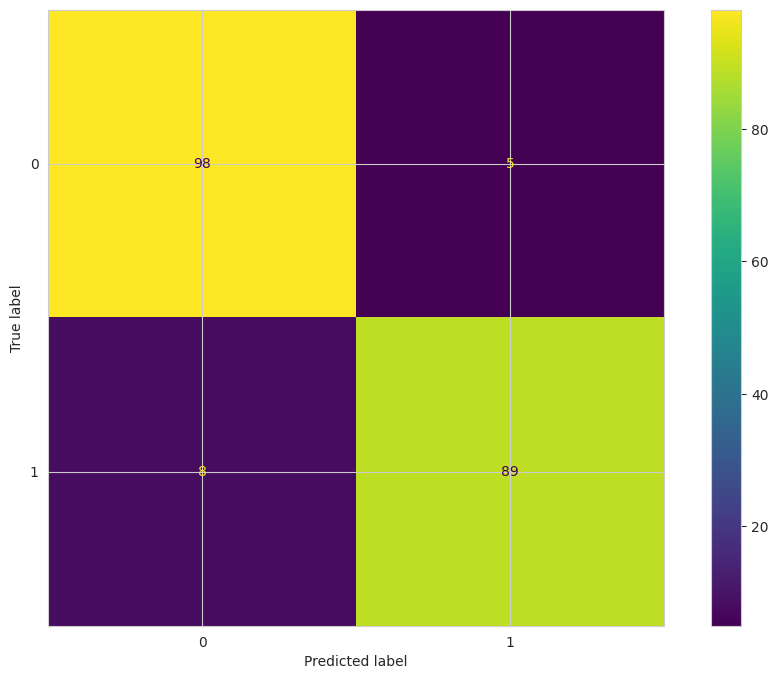

In [37]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_kc)).plot();

### Optimizer ?

![Cost World](adam_cost.jpg)

from https://towardsdatascience.com/the-math-behind-adam-optimizer-c41407efe59b/


#### Types of Optimizer

https://fonzi.ai/blog/machine-learning-optimizers



### Adam Optimizer


![Adam](adam_org.png)

https://arxiv.org/abs/1412.6980
https://github.com/theroyakash/Adam/blob/master/Code/Adam.ipynb

**Adam** (Adaptive Moment Estimation) is a 
- Popular optimization algorithm used in training neural networks. 
- Combine the benefits of momentum (from SGD with momentum) and adaptive learning rates (like RMSProp). 
- Adjust the learning rate for each parameter dynamically based on estimates of first and second moments of the gradients.

> ### First Moment (Mean)
- This is like a moving average of the gradients (estimates the "direction").

$$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t$$

> ### Second Moment (Adaptive-like) for controlling learning rates
- This is a moving average of the squared gradients (estimates the "variance" or scale).

$$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2$$

> ### Bias Correction
- To fix the initial bias (especially important in early steps when moments are close to zero):

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$$

$$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

> ### Parameter Update

$$w_t = w_{t-1} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

> ### Why It Works Well
- **Adaptive**: Different parameters get different effective learning rates.
- **Momentum**: Smooths gradients in the right direction.
- Commonly used in deep learning frameworks like PyTorch and TensorFlow.



### > Compare the Gradient Descent and Adam
- From $m_0 = 0$, $v_0 = 0$, $t = 0$ 
- Compare the Gradient Descent and Adam

$$w_t^{Gradient Descent} = w_{t-1} - \eta \cdot g_t$$

$$w_t^{Adam} = w_{t-1} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$


In [38]:
cost = lambda v: v**2
gradient = lambda v: 2*v

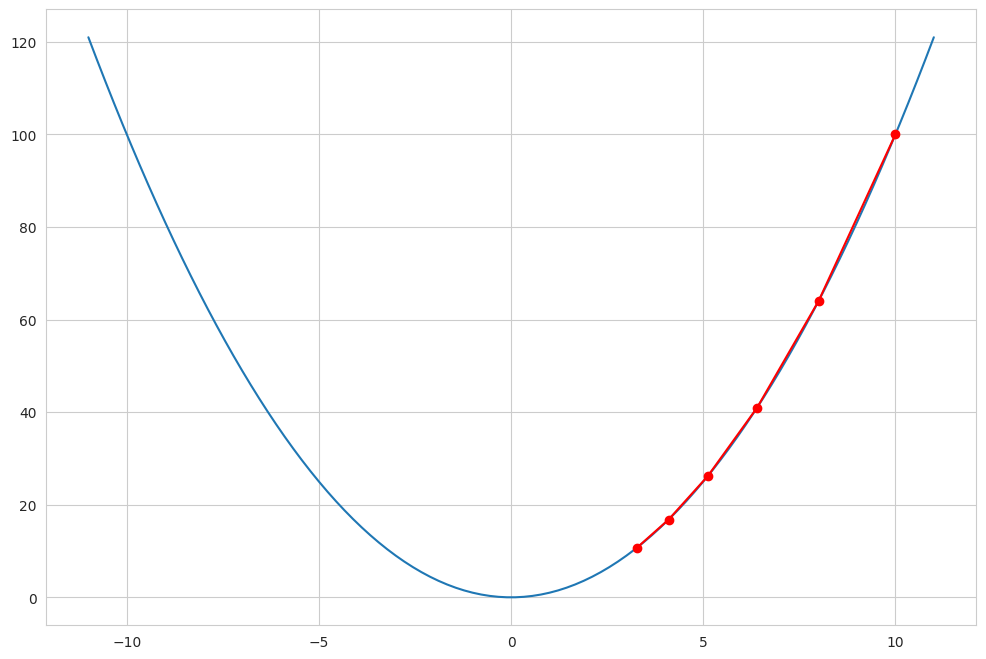

In [54]:
x = np.linspace(-11, 11, 100)
plt.plot(x, cost(x));
plt.plot(track, cost(track), 'ro-');


In [53]:
v=10.0
learning_rate = 0.1
track = [v]

for i in range(5):
    v -= learning_rate * gradient(v)
    track.append(v)
track = np.array(track)
print(track)

[10.      8.      6.4     5.12    4.096   3.2768]


In [57]:
# Momentum
mo = 0
v = 10.0
learning_rate = 0.1
track = [v]

for i in range(5):
    mo = 0.5 * mo + learning_rate * gradient(v)
    v -= mo
    track.append(v)

track = np.array(track)
print(track)

[10.      8.      5.4     3.02    1.226   0.0838]


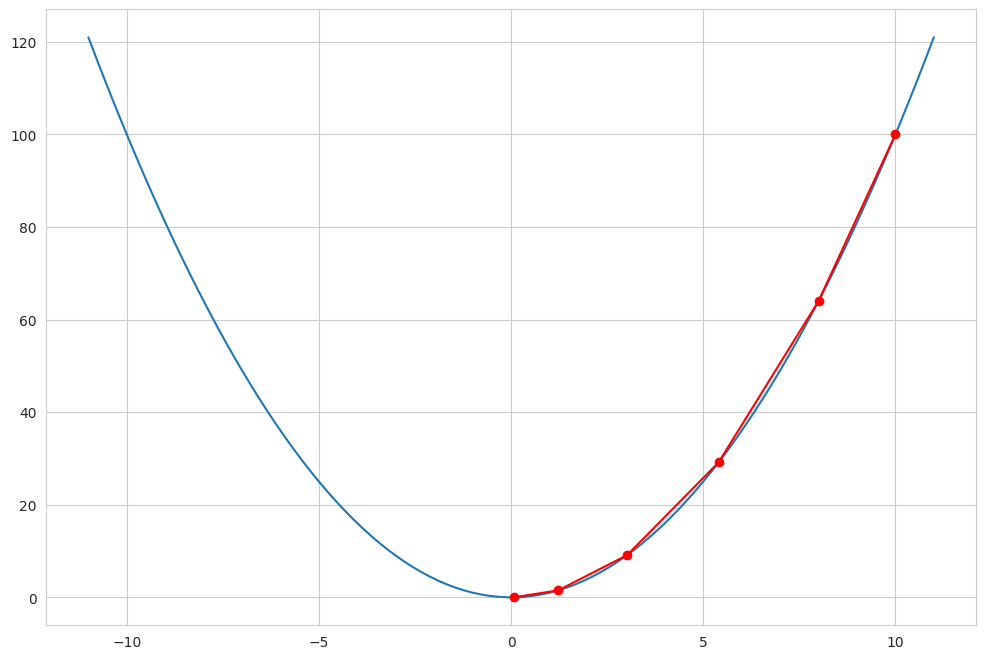

In [58]:
plt.plot(x, cost(x));
plt.plot(track, cost(track), 'ro-')

#### Learning Rate
- Global Learning Rate

In [72]:
v = np.array([1.5, 10.0])
c_p = 50*v[0]**2 + v[1]**2

In [73]:
learning_rate = 0.01
track = [v]

for i in range(5):
    grad = np.array([100 * v[0], 2*v[1]])
    v = v - learning_rate * grad
    track.append(v)
    
track = np.array(track)
print(track.round(2))

[[ 1.5  10.  ]
 [ 0.    9.8 ]
 [ 0.    9.6 ]
 [ 0.    9.41]
 [ 0.    9.22]
 [ 0.    9.04]]


In [80]:
learning_rate = 0.5
epsilon = 0.0001
v = np.array([1.5, 10.0])

g_squared = np.array([0.0, 0.0])
track = [v.copy()]
g_s = [g_squared.copy()]

for i in range(5):
    grad = np.array([100*v[0], 2*v[1]])
    g_squared += grad**2
    
    adpt_lr = learning_rate / (np.sqrt(g_squared)+epsilon)
    v = v - adpt_lr * grad

    track.append(v.copy())
    g_s.append(g_squared.copy())

track = np.array(track)
g_s = np.array(g_s)
print(track)
print(g_s)

[[ 1.5        10.        ]
 [ 1.00000033  9.5000025 ]
 [ 0.72265033  9.15562897]
 [ 0.53661336  8.87911206]
 [ 0.40345798  8.64279025]
 [ 0.30529227  8.4338135 ]]
[[    0.             0.        ]
 [22500.           400.        ]
 [32500.00666666   761.00019   ]
 [37722.2415898   1096.30235733]
 [40601.78061229  1411.65688103]
 [42229.56402358  1710.44817398]]


## Using Pipeline 

Make Dataset using sklearn.datasets.make_classification

In [83]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=18,
    n_redundant=2,
    n_classes=3,
    random_state=123
)

In [84]:
y

array([1, 0, 1, 1, 1, 0, 1, 0, 2, 2, 0, 0, 2, 2, 1, 2, 1, 1, 0, 0, 0, 0,
       0, 2, 2, 1, 0, 2, 0, 2, 0, 1, 2, 1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 0,
       2, 1, 2, 0, 1, 2, 2, 0, 2, 2, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 2, 0, 2, 1, 0, 1, 0, 2, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 0, 2,
       2, 0, 0, 1, 2, 0, 0, 1, 1, 1, 1, 2, 2, 0, 2, 0, 2, 1, 0, 0, 2, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 2, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 0,
       2, 0, 0, 2, 0, 0, 0, 2, 0, 2, 1, 2, 1, 1, 2, 1, 2, 0, 1, 0, 2, 1,
       0, 0, 0, 2, 1, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 2, 0, 1, 1, 1, 1, 0,
       1, 2, 1, 2, 2, 2, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 2, 2, 1, 1,
       2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2, 0, 1, 0, 2, 0, 2, 0, 2, 2, 0, 0,
       1, 0, 0, 0, 2, 1, 0, 1, 2, 0, 0, 0, 0, 2, 1, 2, 0, 2, 0, 2, 2, 0,
       1, 2, 1, 2, 2, 2, 0, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 2, 2, 0, 2, 1, 0, 0, 1, 0, 0, 2, 2, 0, 2, 0, 2, 2, 0, 0,
       0, 2, 2, 1, 2, 1, 1, 0, 0, 2, 0, 1, 1, 2, 0,

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

### Build the Model

In [91]:
def create_model(meta):
    n_features = meta['n_features_in_']
    n_classes = meta['n_classes_']
    
    model = Sequential([
        Dense(64, activation='relu', input_shape=(n_features,)),
        Dropout(0,2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [92]:
ann1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KerasClassifier(model=create_model, epochs=100, batch_size=32, verbose=1))
])

In [93]:
ann1.fit(X_train, y_train);

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5281 - loss: 0.9950
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7790 - loss: 0.5496
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8729 - loss: 0.3447
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9223 - loss: 0.2612
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9346 - loss: 0.1862
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9508 - loss: 0.1671
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9736 - loss: 0.0933
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9830 - loss: 0.0850
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9776 - loss: 0.0762
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9849 - loss: 0.0548
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9741 - loss: 0.0755
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [96]:
dir(ann1.named_steps['model'])

['X_dtype_',
 'X_shape_',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__name__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_keras_model',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_model_compatibility',
 '_check_model_param',
 '_check_n_features',
 '_compile_kwargs',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_ensure_compiled_model',
 '_estimator_type',
 '_fit',
 '_fit_callbacks',
 '_fit_keras_model',
 '_fit_kwargs',
 '_get_compile_kwargs',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',


In [100]:
# Predict
y_pred_ann1 = ann1.named_steps['model'].predict(X_test)
y_pred_prob_ann1 = ann1.named_steps['model'].predict_proba(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [103]:
np.c_[y_test, y_pred_ann1, y_pred_prob_ann1.round(3)]


array([[0.        , 0.        , 1.        , 0.        , 0.        ],
       [1.        , 1.        , 0.        , 1.        , 0.        ],
       [2.        , 2.        , 0.        , 0.        , 1.        ],
       [2.        , 2.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 0.99800003, 0.002     , 0.        ],
       [1.        , 1.        , 0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ],
       [2.        , 2.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ],
       [2.        , 2.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ],
       [2.        , 0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.

In [104]:
# Evaluate
ann1.named_steps['model'].score(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


0.885

In [107]:
print(classification_report(y_test, y_pred_ann1))
confusion_matrix(y_test, y_pred_ann1)

              precision    recall  f1-score   support

           0       0.87      0.92      0.89        71
           1       0.91      0.86      0.88        69
           2       0.88      0.88      0.88        60

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200



array([[65,  4,  2],
       [ 5, 59,  5],
       [ 5,  2, 53]])

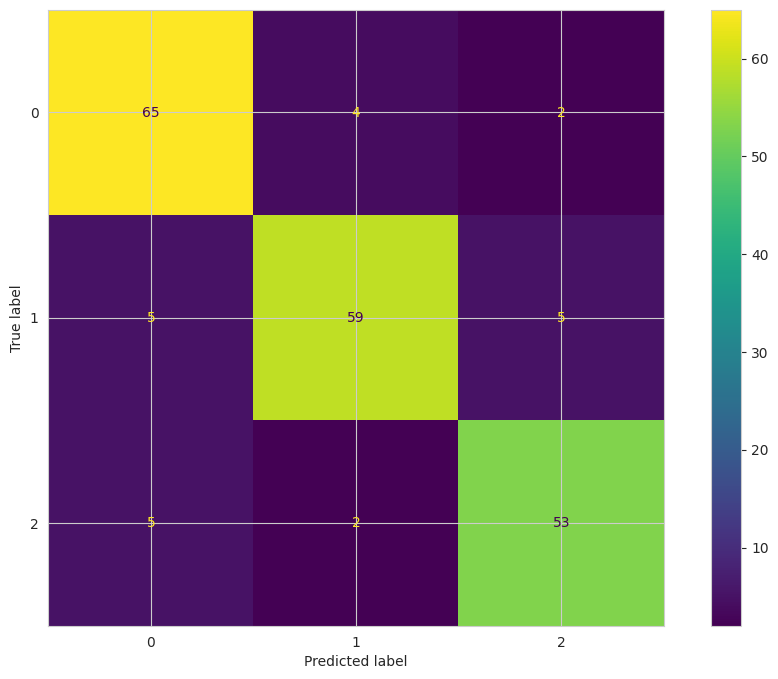

In [108]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ann1)).plot();

## Hyperparameter Tuning with RandomizedSearchCV 
- Possible Option: GridSearchCV
- Speed (control iterations)
- Continuous space
- Lower risk of overfitting

In [109]:
from sklearn.model_selection import RandomizedSearchCV

In [110]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=18,
    n_redundant=2,
    n_classes=2,
    random_state=123
)

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [118]:
def create_model(meta, n_hidden=3, n_neurons=64, learning_rate=0.01):
    n_features = meta['n_features_in_']
    model = Sequential()
    model.add(Input(shape=(n_features, )))
    
    for _ in range(n_hidden):
        model.add(Dense(n_neurons, activation= 'relu'))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    
    return model
    
        

In [119]:
ann_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KerasClassifier(model=create_model, epochs=100, batch_size=32, verbose=0))
])

In [117]:
ann_pip1 = ann_pipeline.fit(X_train, y_train);

In [120]:
param_dist = {
    'model__model__n_hidden': [2, 4],
    'model__model__n_neurons': [30, 50],
    'model__model__learning_rate': [0.05, 0.1],
    'model__batch_size': [20, 50]
}

rnd_search = RandomizedSearchCV(estimator=ann_pip1, param_distributions=param_dist,
                                n_iter=5, cv=3, verbose=0)

In [122]:
rnd_search.fit(X_train, y_train);

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('model',
                                              KerasClassifier(batch_size=32, epochs=100, model=<function create_model at 0x7a1636573b00>, verbose=0))]),
                   n_iter=5,
                   param_distributions={'model__batch_size': [20, 50],
                                        'model__model__learning_rate': [0.05,
                                                                        0.1],
                                        'model__model__n_hidden': [2, 4],
                                        'model__model__n_neurons': [30, 50]})